In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
points={
    'A': [1.0, 2.0,5.6],
    'B': [1.5, 1.8,8.0],
    'C': [5.0, 8.0,1.2],
    'D': [8.0, 8.0,4.9],
    'E': [1.0, 0.6,0.7],
    'F': [9.0, 11.0,3.4]


}

In [4]:
points

{'A': [1.0, 2.0, 5.6],
 'B': [1.5, 1.8, 8.0],
 'C': [5.0, 8.0, 1.2],
 'D': [8.0, 8.0, 4.9],
 'E': [1.0, 0.6, 0.7],
 'F': [9.0, 11.0, 3.4]}

In [5]:
#Convert to numpy array for calculation
data = np.array(list(points.values()))
labels = list(points.keys())



In [6]:
data

array([[ 1. ,  2. ,  5.6],
       [ 1.5,  1.8,  8. ],
       [ 5. ,  8. ,  1.2],
       [ 8. ,  8. ,  4.9],
       [ 1. ,  0.6,  0.7],
       [ 9. , 11. ,  3.4]])

In [7]:
labels

['A', 'B', 'C', 'D', 'E', 'F']

In [8]:
# Extract x, y coordinates
x = [v[0] for v in points.values()]
y = [v[1] for v in points.values()]


In [9]:
x

[1.0, 1.5, 5.0, 8.0, 1.0, 9.0]

In [10]:
y

[2.0, 1.8, 8.0, 8.0, 0.6, 11.0]

In [11]:
x = []
y = []
colors = []


In [12]:

# Assign unique color for each label
color_map = {
    'A': 'red',
    'B': 'blue',
    'C': 'green',
    'D': 'purple',
    'E': 'orange',
    'F': 'cyan'
}


In [13]:

# Populate data
for label in points:
    for i, value in enumerate(points[label]):
        x.append(i)  # Just using index (0, 1, 2) for x-axis
        y.append(value)
        colors.append(color_map[label])


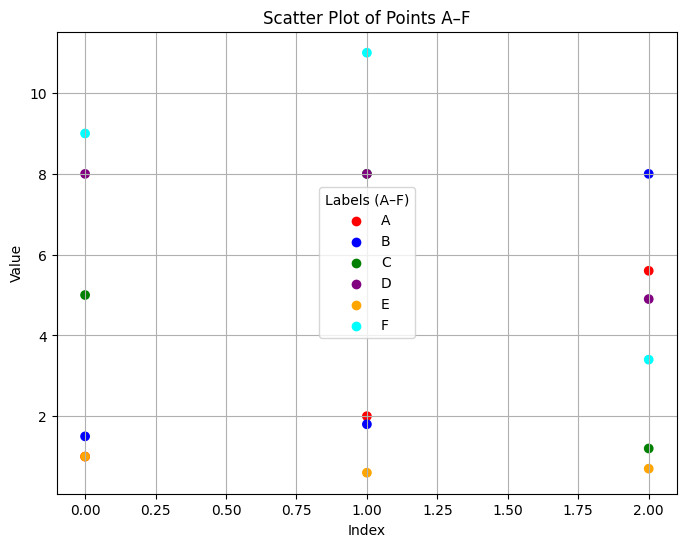

In [14]:

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=colors)

# Add legend manually
for label in points:
    plt.scatter([], [], c=color_map[label], label=label)

plt.legend(title='Labels (A–F)')
plt.title('Scatter Plot of Points A–F')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

In [15]:
# Number of clusters
k = 2


In [16]:
# Step 1: Initialize centroids randomly
np.random.seed(0)
initial_indices = np.random.choice(len(data), k, replace=False)
centroids = data[initial_indices]


In [17]:
centroid1=centroids[0]
print(centroid1)

[ 9.  11.   3.4]


In [18]:
centroid2=centroids[1]
print(centroid2)

[5.  8.  1.2]


In [19]:
#Step 3: Assign each point to the closest centroid
labels = []
for point in data:
    dist1 = np.linalg.norm(point - centroid1)  # Euclidean distance to centroid1
    dist2 = np.linalg.norm(point - centroid2)  # Euclidean distance to centroid2

    # Assign to the closest centroid
    if dist1 < dist2:
        labels.append(0)
        print(f"Point {point} is closer to Centroid 1 → Cluster 0")
    else:
        labels.append(1)
        print(f"Point {point} is closer to Centroid 2 → Cluster 1")

Point [1.  2.  5.6] is closer to Centroid 2 → Cluster 1
Point [1.5 1.8 8. ] is closer to Centroid 2 → Cluster 1
Point [5.  8.  1.2] is closer to Centroid 2 → Cluster 1
Point [8.  8.  4.9] is closer to Centroid 1 → Cluster 0
Point [1.  0.6 0.7] is closer to Centroid 2 → Cluster 1
Point [ 9.  11.   3.4] is closer to Centroid 1 → Cluster 0


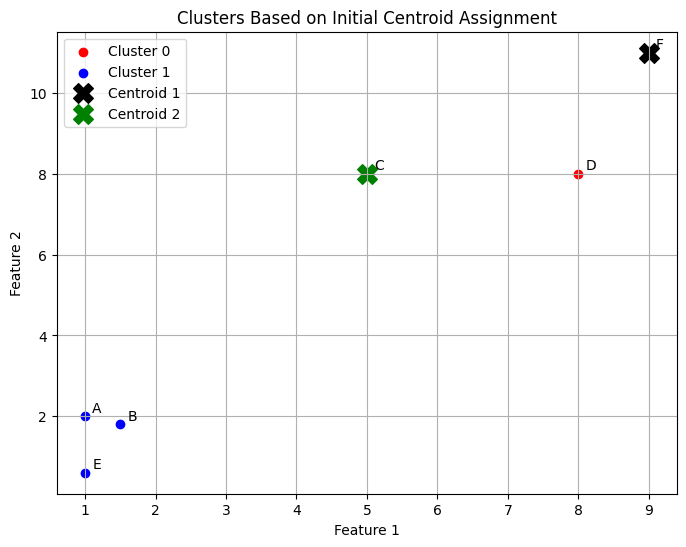

In [21]:
labels_text = list(points.keys())

labels = np.array(labels)

# Step 3: Visualize Clusters (only first two dimensions)
plt.figure(figsize=(8, 6))

# Plot Cluster 0
plt.scatter(data[labels == 0][:, 0], data[labels == 0][:, 1], color='red', label='Cluster 0')
# Plot Cluster 1
plt.scatter(data[labels == 1][:, 0], data[labels == 1][:, 1], color='blue', label='Cluster 1')

# Plot centroids
plt.scatter(centroid1[0], centroid1[1], color='black', marker='X', s=200, label='Centroid 1')
plt.scatter(centroid2[0], centroid2[1], color='green', marker='X', s=200, label='Centroid 2')

# Add point labels
for i, txt in enumerate(labels_text):
    plt.annotate(txt, (data[i][0] + 0.1, data[i][1] + 0.1))

plt.title("Clusters Based on Initial Centroid Assignment")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# Function to assign points to the closest centroid
def assign_clusters(data, centroids):
    labels = []
    for point in data:
        distances = [np.linalg.norm(point - centroid) for centroid in centroids]
        labels.append(np.argmin(distances))  # Cluster index (0 or 1)
    return np.array(labels)


In [23]:

# Function to update centroids based on current labels
def update_centroids(data, labels, k):
    new_centroids = []
    for i in range(k):
        cluster_points = data[labels == i]
        if len(cluster_points) > 0:
            new_centroid = np.mean(cluster_points, axis=0)
        else:
            new_centroid = centroids[i]  # Keep the old one if no points
        new_centroids.append(new_centroid)
    return np.array(new_centroids)


In [24]:

# Loop until convergence or max iterations
max_iter = 100
k = 2
for i in range(max_iter):
    labels = assign_clusters(data, centroids)
    new_centroids = update_centroids(data, labels, k)

    print(f"\nIteration {i+1}")
    print("Labels:", labels)
    print("Centroids:\n", new_centroids)

    # If centroids do not change, break (convergence)
    if np.allclose(centroids, new_centroids):
        print("\n Converged!")
        break
    centroids = new_centroids


Iteration 1
Labels: [1 1 1 0 1 0]
Centroids:
 [[8.5   9.5   4.15 ]
 [2.125 3.1   3.875]]

Iteration 2
Labels: [1 1 0 0 1 0]
Centroids:
 [[7.33333333 9.         3.16666667]
 [1.16666667 1.46666667 4.76666667]]

Iteration 3
Labels: [1 1 0 0 1 0]
Centroids:
 [[7.33333333 9.         3.16666667]
 [1.16666667 1.46666667 4.76666667]]

 Converged!


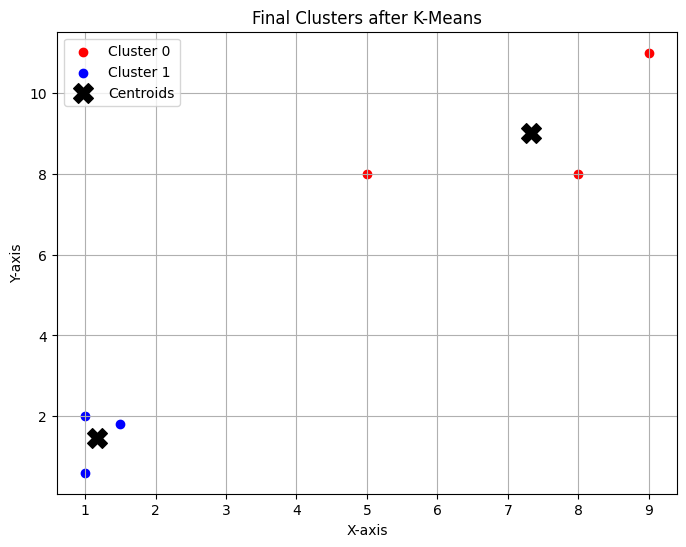

In [25]:
# Final scatter plot
plt.figure(figsize=(8, 6))
colors = ['red', 'blue']
for i in range(k):
    cluster_points = data[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i], label=f'Cluster {i}')
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.title("Final Clusters after K-Means")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.grid(True)
plt.show()
